In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("bank-full.csv", sep=';', index_col=0)
df.head()

,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
age,,,,,,,,,,,,,,,,
58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45211 entries, 58 to 37
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   job        45211 non-null  object
 1   marital    45211 non-null  object
 2   education  45211 non-null  object
 3   default    45211 non-null  object
 4   balance    45211 non-null  int64 
 5   housing    45211 non-null  object
 6   loan       45211 non-null  object
 7   contact    45211 non-null  object
 8   day        45211 non-null  int64 
 9   month      45211 non-null  object
 10  duration   45211 non-null  int64 
 11  campaign   45211 non-null  int64 
 12  pdays      45211 non-null  int64 
 13  previous   45211 non-null  int64 
 14  poutcome   45211 non-null  object
 15  y          45211 non-null  object
dtypes: int64(6), object(10)
memory usage: 5.9+ MB


In [8]:
df.describe()

,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [9]:
df.shape

(45211, 16)

In [11]:
import math
def entropy(labels):
    total=len(labels)
    counts=labels.value_counts()

    e=0

    for c in counts:
        p=c/total
        e-=p*math.log2(p)

    return e

print("Parent Entropy = ",round(entropy(df["loan"]),4))

Parent Entropy =  0.6349


In [12]:
def information_gain(data,feature,target):
    parent_entropy=entropy(data[target])
    weighted_entropy=0

    for value in data[feature].unique():
        subset=data[data[feature]==value]

        weighted_entropy+=(len(subset)/len(data))*entropy(subset[target])
    
    return parent_entropy-weighted_entropy


In [ ]:
features=['housing','marital']

for feature in features:
    gain=information_gain(df,feature,"loan")
    print(f"{feature:15} -> {gain:.4f}")

housing         -> 0.0012
marital         -> 0.0020


In [16]:
best_feature=max(features,key=lambda\
                 f:information_gain(df,f,"loan"))
print("Best feature = ",best_feature)

Best feature =  marital


In [17]:
def id3(data,target,features,depth=0):
    labels=data[target]

# Base Condition 1
    if len(labels.unique())==1:
        return labels.iloc[0]

# Base Condition 2
    if len(features)==0:
        return labels.mode()[0]

    gains={f:information_gain(data,f,target) for f in features}

    best=max(gains,key=gains.get)

    tree={best:{}}

    remaining=[f for f in features if f!=best]

    for value in data[best].unique():

        subset=data[data[best]==value]

        if subset.empty:
            tree[best][value]=labels.mode()[0]
        else:
            tree[best][value]=id3(
                subset.drop(columns=[best]),
                target,
                remaining,
                depth+1
            )

    return tree
tree=id3(df,"loan",["marital","housing"])
tree

{'marital': {'married': {'housing': {'yes': 'no', 'no': 'no'}},
  'single': {'housing': {'yes': 'no', 'no': 'no'}},
  'divorced': {'housing': {'yes': 'no', 'no': 'no'}}}}

In [18]:
def predict(tree,sample):
    if not isinstance(tree,dict):
        return tree

    root=list(tree.keys())[0]

    value=sample[root]

    child=tree[root].get(value)

    if child is None:
        return "Unknown"

    return predict(child,sample)

In [22]:
candidate={
    "marital":'single',
    "housing":"yes"
}

print(candidate)
print("prediction = ",predict(tree,candidate))

{'marital': 'single', 'housing': 'yes'}
prediction =  no


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


X = df[['housing', 'marital']]
y = df['loan']


X_encoded = pd.get_dummies(X, drop_first=True)  
y_encoded = y.map({'yes': 1, 'no': 0})          


X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)


model = DecisionTreeClassifier(
    criterion="entropy", 
    max_depth=5, 
    random_state=42
)


model.fit(X_train, y_train)
prediction = model.predict(X_test)
print("Accuracy :", accuracy_score(y_test, prediction))


Accuracy : 0.8441888753732169


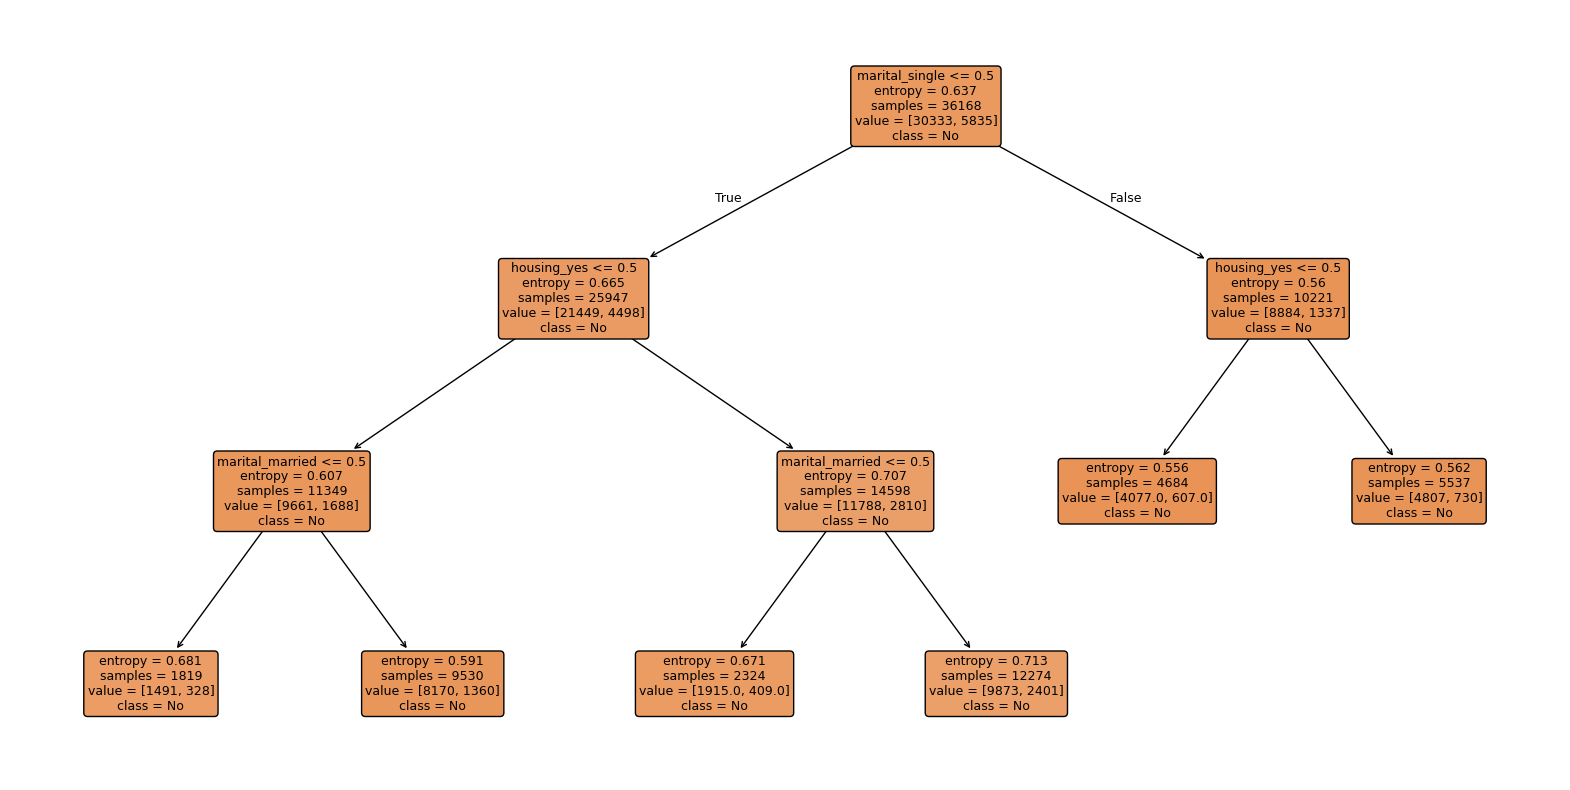

In [28]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


plt.figure(figsize=(20, 10))


plot_tree(
    model,
    feature_names=X_encoded.columns, 
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.show()
